# Planning course graded exercice #2

This exercice will give you a glimpse into near-realistic flight planning with the open source aircraft performance model [openap](https://openap.dev/).

First, we get the main imports of the notebook from scikit-decide since openap is provided as a flight planning domain in scikit-decide.

In [1]:
import datetime

import numpy as np
from openap.extra.aero import cas2mach, ft, kts
from openap.extra.nav import airport
from pygeodesy.ellipsoidalVincenty import LatLon

from skdecide.hub.domain.flight_planning.aircraft_performance.bean.aircraft_state import (
    AircraftState,
)
from skdecide.hub.domain.flight_planning.aircraft_performance.performance.performance_model_enum import (
    PerformanceModelEnum,
)
from skdecide.hub.domain.flight_planning.aircraft_performance.performance.phase_enum import (
    PhaseEnum,
)
from skdecide.hub.domain.flight_planning.aircraft_performance.performance.rating_enum import (
    RatingEnum,
)
from skdecide.hub.domain.flight_planning.domain import FlightPlanningDomain, WeatherDate
from skdecide.hub.domain.flight_planning.flightplanning_utils import (
    plot_network_adapted,
)
from skdecide.hub.solver.astar import Astar

First, we set the date for the weather data to today. You can change the day if you remember a recent stormy day..

In [2]:
today = datetime.date.today()
weather_date = None
print(weather_date)

None


We then define the aircraft state, which includes the aircraft performance model -- in this case a A320 aircraft.

We assume the aircraft is flying at 30000 feet at 250 knots and is weighting 80 tons.

In [3]:
acState = AircraftState(
    model_type="A320",  # only for OPENAP and POLL_SCHUMANN
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=30_000,
    mach=cas2mach(250 * kts, h=30_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

We now define the flight planning domain, optimizing for fuel burn minimization. Other options are distance and time minimization.

The heuristic function is used by the A\* solver, it can be one of 'time', 'distance', 'lazy_fuel', 'lazy_time' or None, in which case the heuristic value will be the constant 0.

In [4]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="fuel",
    heuristic_name="lazy_fuel",
    weather_date=weather_date,
)

domain = domain_factory()

d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


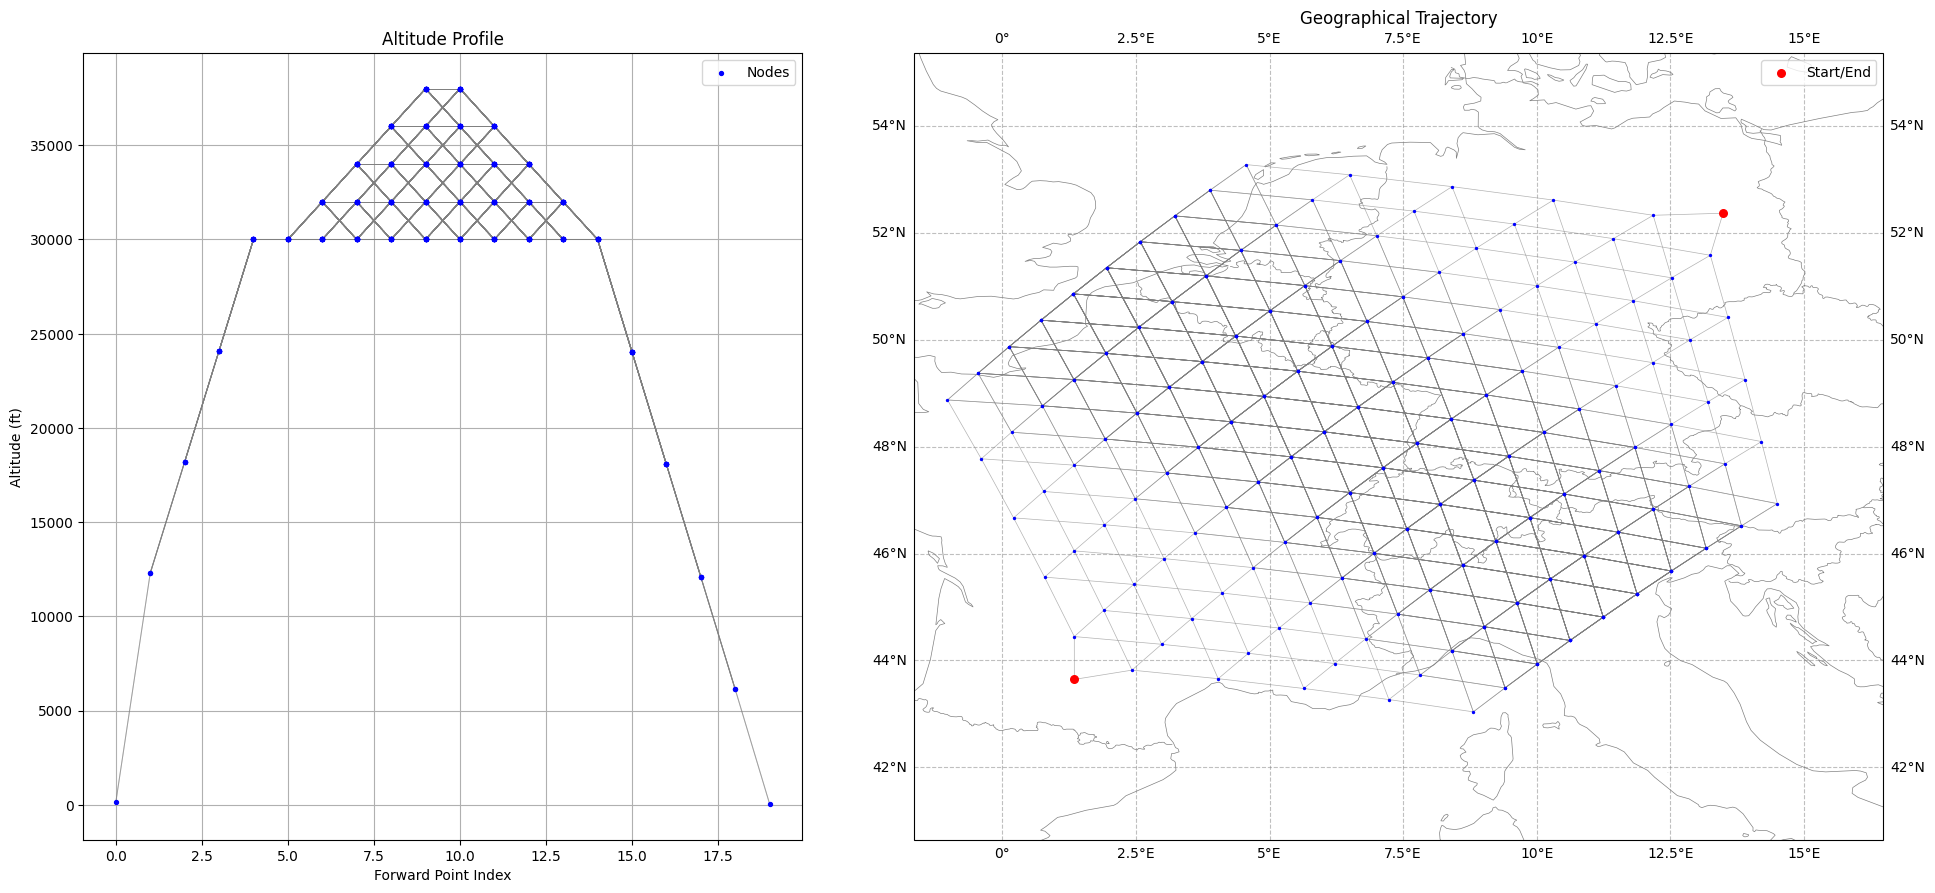

In [ ]:
plot_network_adapted(
    graph=domain.network,
    p0=LatLon(
        airport("LFBO")["lat"], airport("LFBO")["lon"], airport("LFBO")["alt"] * ft
    ),
    p1=LatLon(
        airport("EDDB")["lat"], airport("EDDB")["lon"], airport("EDDB")["alt"] * ft
    ),
)

Let's solve the problem with the A\* algorithm from scikit-decide.

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


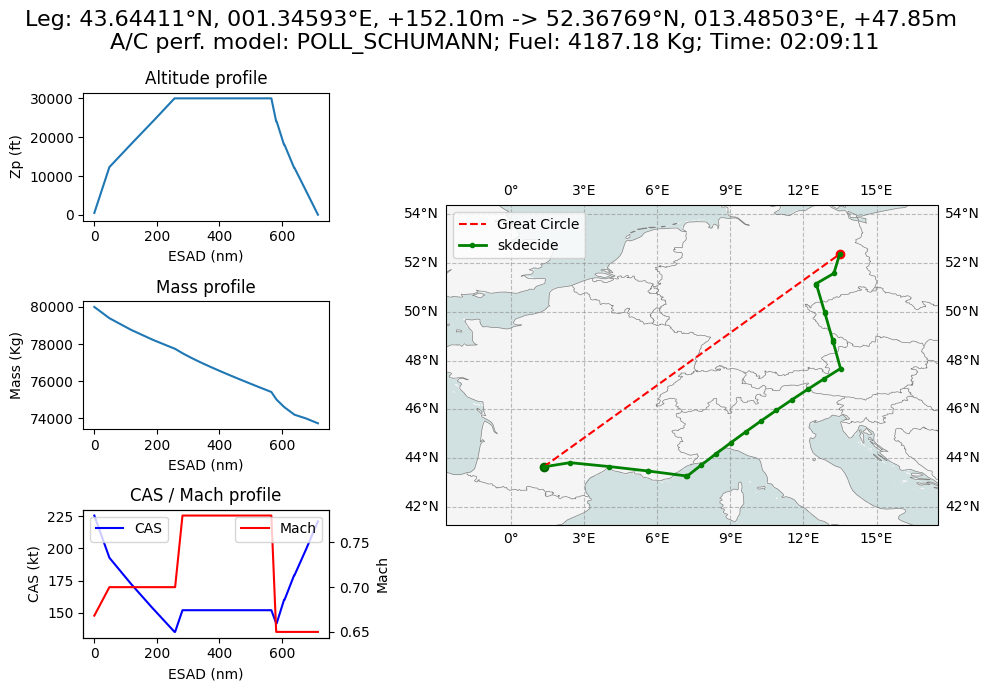

Goal reached after 19 steps!


In [5]:
with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

***
## Optimize for distance and time too, and compare the resulting trajectory and profiles with the ones obtained when minimizing the fuel.

### Optimising for time
#### We change the objective and heuristic_name to "time"

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


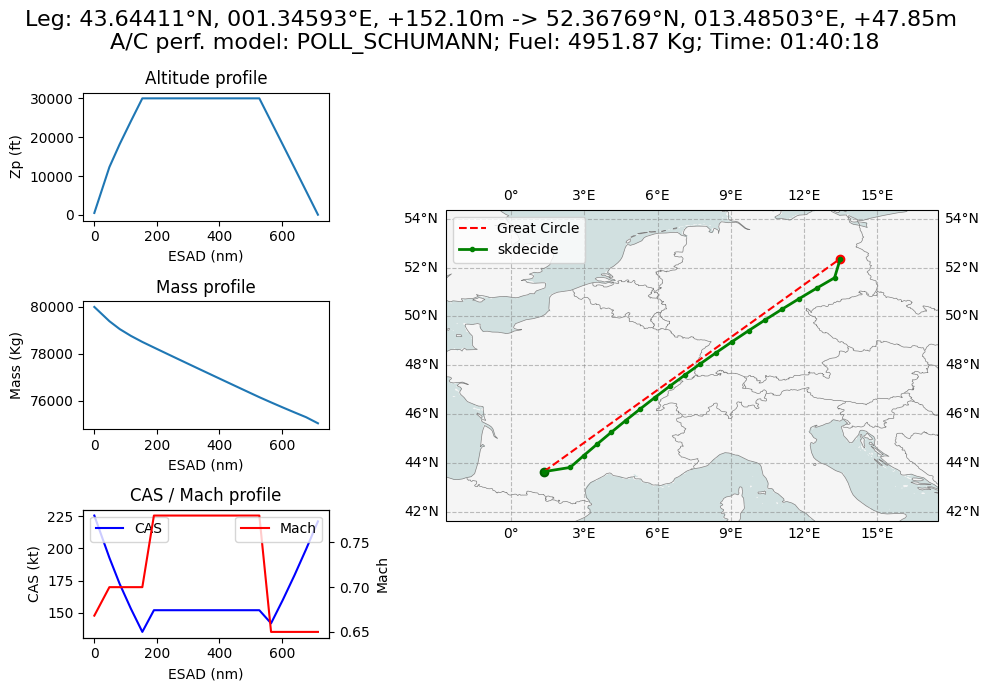

Goal reached after 19 steps!


In [ ]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="time",
    heuristic_name="time",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

### Optimising for distance

#### We change the objective and heuristic_name to "distance"

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


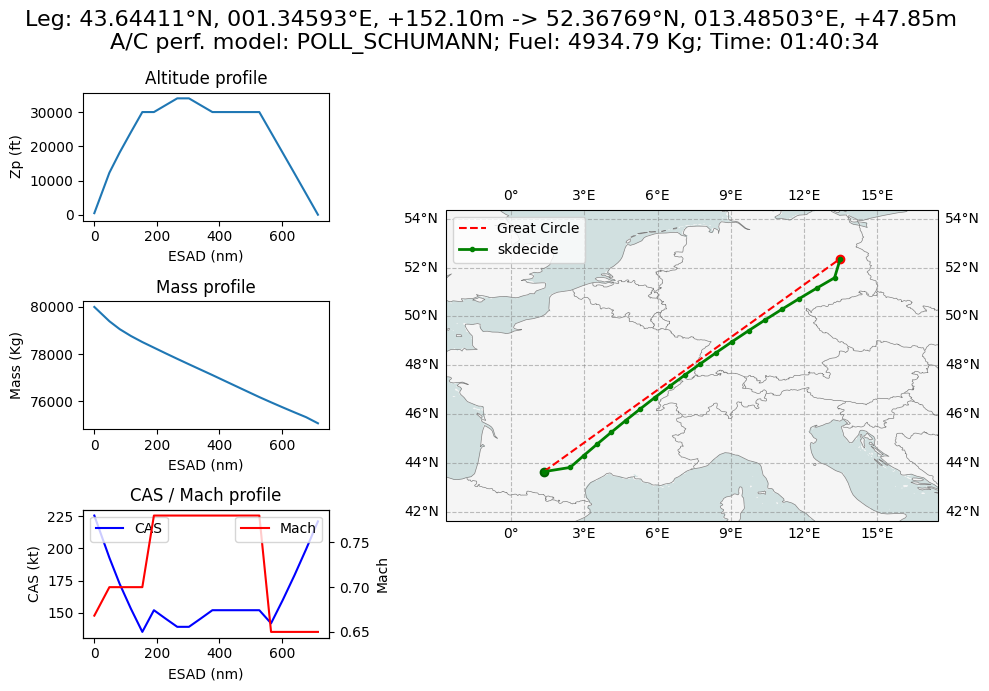

Goal reached after 19 steps!


In [8]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

***
## Study the impact of aircraft weight, altitude and speed on the resulting trajectory and profiles.

### Studying weight impact

#### Lighter at 55 tons

In [13]:
acState = AircraftState(
    model_type="A320",
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=55_000,
    zp_ft=30_000,
    mach=cas2mach(250 * kts, h=30_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


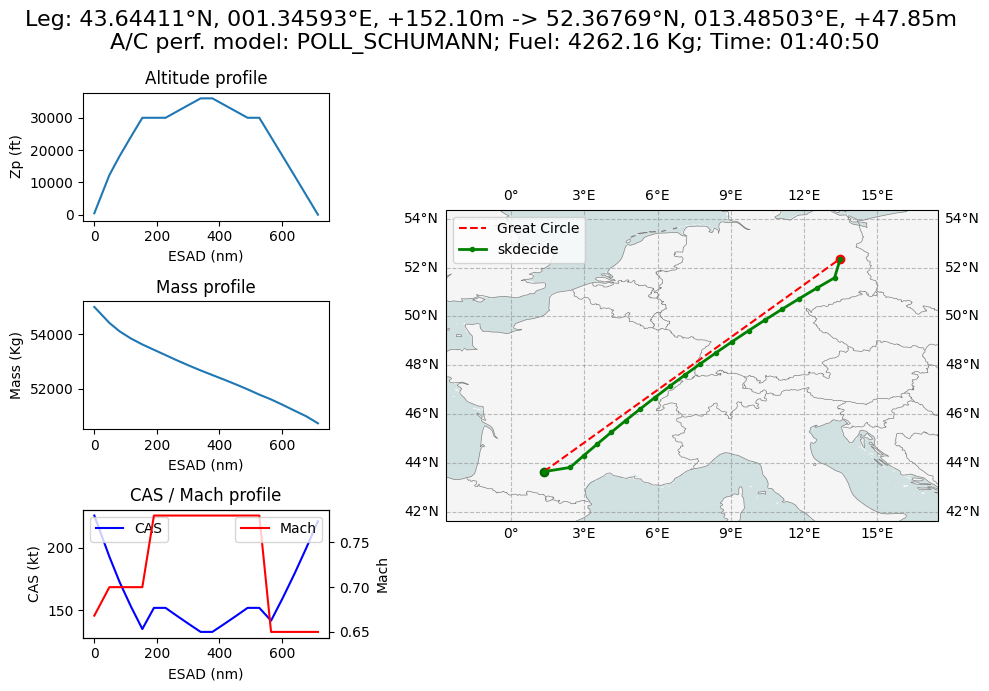

Goal reached after 19 steps!


In [10]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

#### Heavier at 105 tons

In [11]:
acState = AircraftState(
    model_type="A320",
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=105_000,
    zp_ft=30_000,
    mach=cas2mach(250 * kts, h=30_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


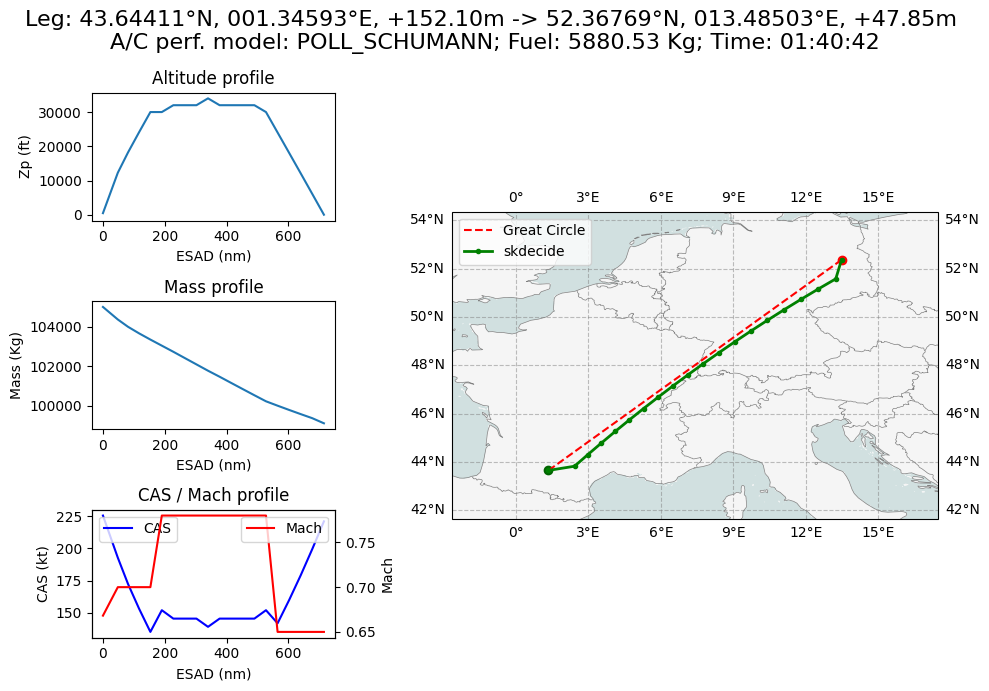

Goal reached after 19 steps!


In [12]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

#### Impact of weight change findings.

***
### Studying altitude impact
#### Lower cruise altitude at 25_000 feet

In [19]:
acState = AircraftState(
    model_type="A320",
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=25_000,
    mach=cas2mach(250 * kts, h=25_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


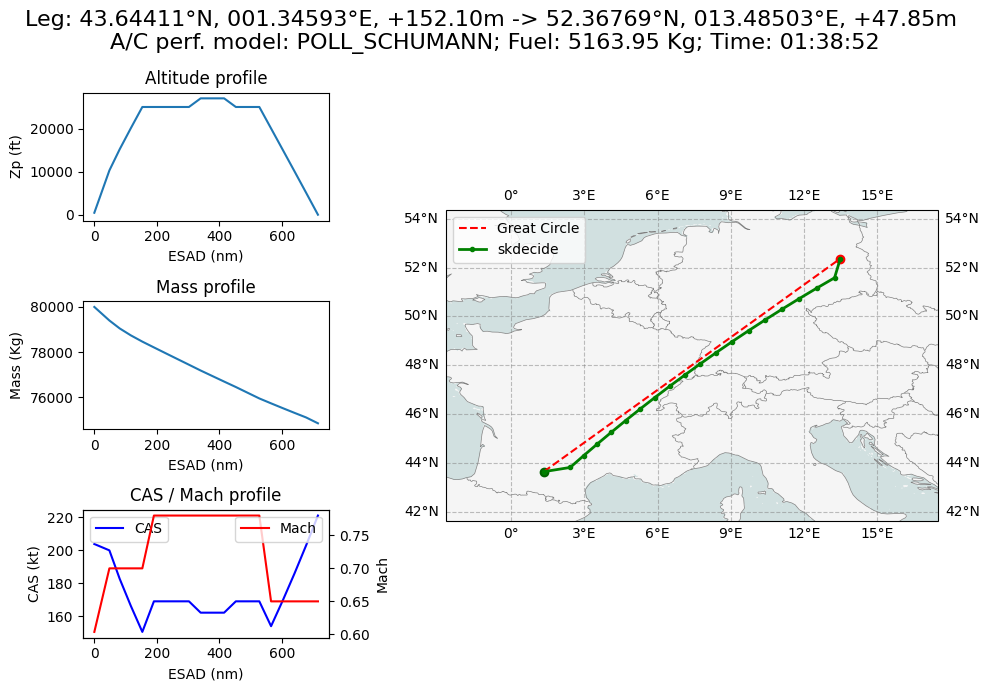

Goal reached after 19 steps!


In [20]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(25_000, 33_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

#### Higher cruise altitude at 35_000 feet

In [21]:
acState = AircraftState(
    model_type="A320",
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=35_000,
    mach=cas2mach(250 * kts, h=35_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


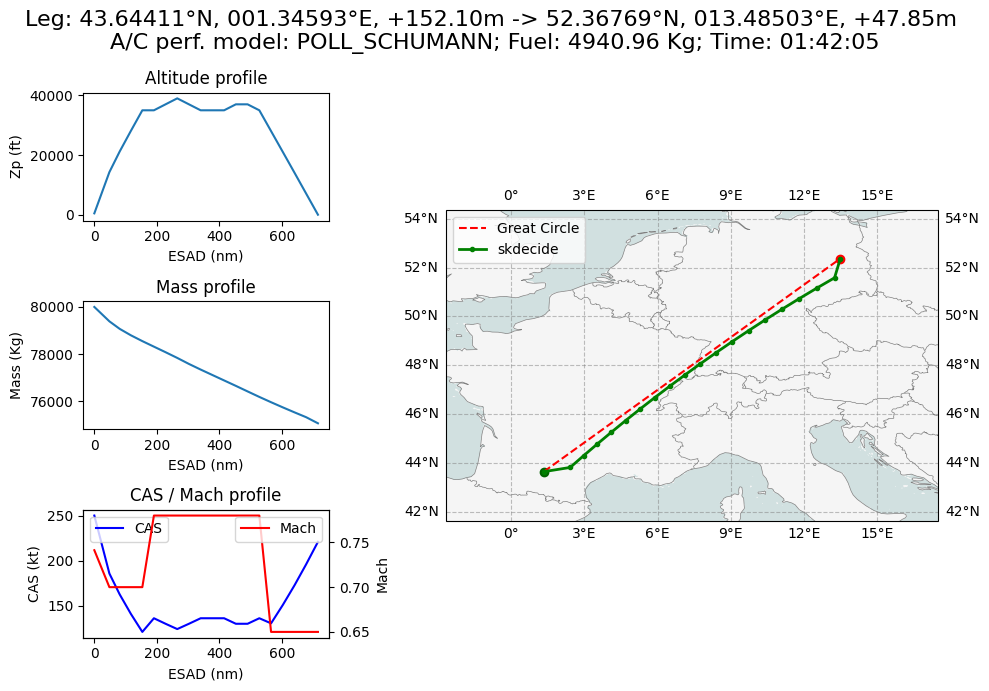

Goal reached after 19 steps!


In [22]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(35_000, 43_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

#### Impact of cruise altitude change findings.

***
### Studying cruise speed impact
#### Lower speed at 200 mach during cruise

In [23]:
acState = AircraftState(
    model_type="A320",
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=30_000,
    mach=cas2mach(200 * kts, h=30_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


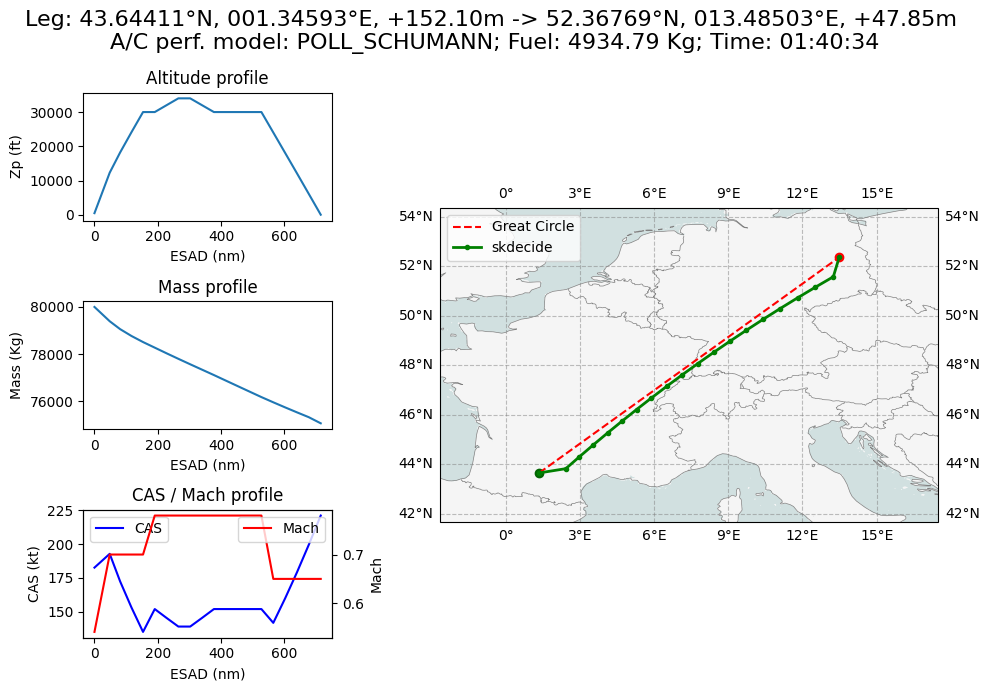

Goal reached after 19 steps!


In [24]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

#### Higher speed at 300 mach during cruise

In [25]:
acState = AircraftState(
    model_type="A320",
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=30_000,
    mach=cas2mach(300 * kts, h=30_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


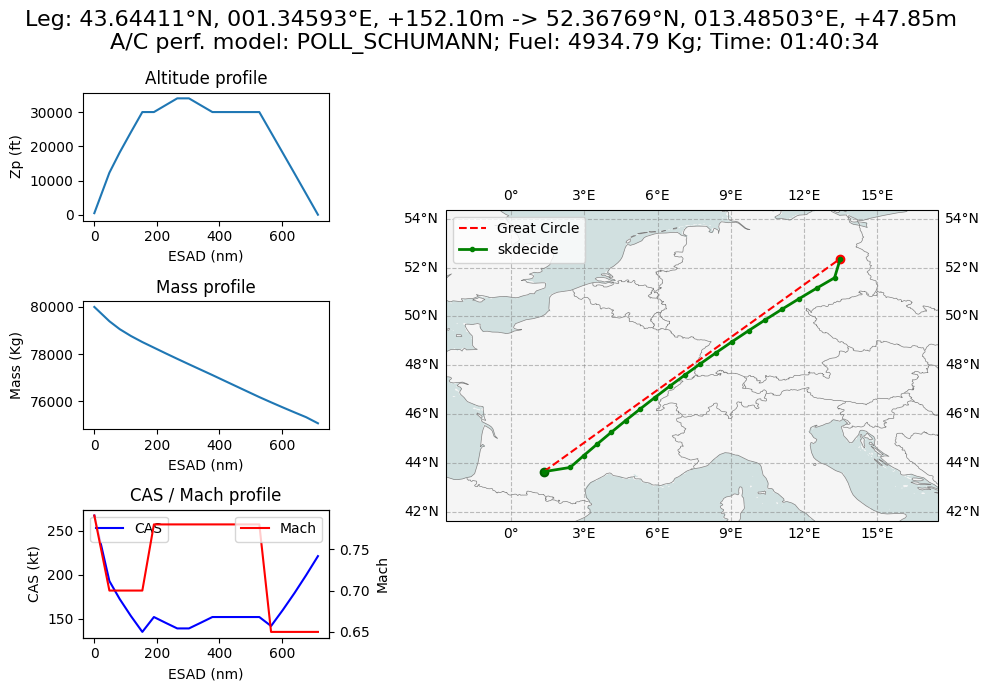

Goal reached after 19 steps!


In [26]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="distance",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()


with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

#### Impact of cruise speed change findings.